# 📊 Cross-Channel Audience Analytics: Top Comments & Subscription Mining for Similar Channels

## 📌 Executive Summary & Methodology
This notebook performs cross-channel audience intelligence by ingesting the **Top 10 Most Relevant Channels** identified in the preceding filtering stage (`5.Youtube_channel_relevance_filtering.ipynb`). For each similar channel, it fetches up to 10 recent long-form videos (>60 seconds) and extracts up to **50 top-liked/relevant comments** per video using the **YouTube Data API v3** (`commentThreads.list`). Subsequently, it isolates unique comment authors and mines their public channel subscriptions (`subscriptions.list`) to uncover aggregated cross-channel audience consumption patterns.

### 🔬 Analytical Pipeline & Mathematical Formulation:
1. **Dataset Ingestion**: Ingests `{Channel_Name}_top_10_relevant_channels.json` (or `.csv`) to extract candidate similar channels $C_{\text{sim}} = \{c_1, c_2, \dots, c_K\}$ where $K \le 10$.
2. **Long-Form Video Isolation**: For each similar channel $c_k$, queries `playlistItems.list` on long-form uploads playlist `UULF...` to isolate recent videos $V(c_k)$ with ISO 8601 duration $T(v) > 60\text{s}$.
3. **Top Comment Extraction**: For each video $v \in V(c_k)$, fetches top $M=50$ comments ordered by relevance/likes:
   $$\mathcal{D}_{\text{comments}} = \bigcup_{k=1}^{K} \bigcup_{v \in V(c_k)} \text{TopComments}(v, M)$$
4. **Author Subscription Graph Mining**: Extracts unique comment authors $A = \{a_1, a_2, \dots, a_N\}$ and fetches public subscriptions $S(a)$. Handles `subscriptionForbidden` (403 HTTP errors) gracefully.
5. **Cross-Channel Subscription Frequency Aggregation**: Computes audience overlap frequencies across public authors $A_{\text{public}}$:
   $$f(s) = \sum_{a \in A_{\text{public}}} \mathbb{I}(s \in S(a))$$
6. **Dual-Payload Artifact Exports**: Exports top comments and aggregated subscriptions into separate CSV and JSON files stored in Google Drive (`/content/drive/MyDrive/YouTube_Analytics/`) and local fallback directories.


## ⚙️ 1. Configuration & Setup

Configures runtime parameters, package dependencies, target channel identifiers, limits for video/comment harvesting, and API key lookup configurations.


In [20]:
# Install required packages if missing
!pip install -q google-api-python-client pandas matplotlib seaborn isodate

import os
import re
import sys
import json
import time
import datetime
import isodate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError

# Global Configuration Parameters
CONFIG = {
    "CHANNEL_IDENTIFIER": "Casa Siete",  # Target channel identifier or channel ID
    "TOP_SIMILAR_CHANNELS_LIMIT": 10,   # Max number of similar channels from previous notebook
    "MAX_VIDEOS_PER_CHANNEL": 10,       # Max recent long-form videos per similar channel
    "MAX_COMMENTS_PER_VIDEO": 50,       # Max top comments per video (order=relevance)
    "MOUNT_DRIVE": True,                 # Whether to attempt Google Drive mounting
    "DRIVE_OUTPUT_DIR": "/content/drive/MyDrive/YouTube_Analytics",
    "USE_CACHE": True                    # Check local/Drive cache before API fetching
}

print("⚙️ Configuration successfully initialized:")
print(json.dumps(CONFIG, indent=2))


⚙️ Configuration successfully initialized:
{
  "CHANNEL_IDENTIFIER": "Casa Siete",
  "TOP_SIMILAR_CHANNELS_LIMIT": 10,
  "MAX_VIDEOS_PER_CHANNEL": 10,
  "MAX_COMMENTS_PER_VIDEO": 50,
  "MOUNT_DRIVE": true,
  "DRIVE_OUTPUT_DIR": "/content/drive/MyDrive/YouTube_Analytics",
  "USE_CACHE": true
}


## 💾 2. Mount Google Drive & Storage Hierarchy

Mounts Google Drive at `/content/drive` if running inside Google Colab. Establishes an adaptive fallback storage hierarchy (`/content/drive/MyDrive/YouTube_Analytics`, `data/`, `analysis/`, `.`) to ensure seamless code execution across both Colab and local environments.


In [21]:
ACTIVE_OUTPUT_DIR = "."

if CONFIG["MOUNT_DRIVE"]:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        ACTIVE_OUTPUT_DIR = CONFIG["DRIVE_OUTPUT_DIR"]
        os.makedirs(ACTIVE_OUTPUT_DIR, exist_ok=True)
        print(f"✅ Mounted Google Drive successfully. Active output directory: {ACTIVE_OUTPUT_DIR}")
    except ImportError:
        print("ℹ️ Google Colab environment not detected. Utilizing local directory fallback storage.")
        ACTIVE_OUTPUT_DIR = "data"
        os.makedirs(ACTIVE_OUTPUT_DIR, exist_ok=True)
    except Exception as e:
        print(f"⚠️ Unable to mount Google Drive: {e}. Fallback directory established: {ACTIVE_OUTPUT_DIR}")
else:
    ACTIVE_OUTPUT_DIR = "data"
    os.makedirs(ACTIVE_OUTPUT_DIR, exist_ok=True)

def sanitize_filename(name: str) -> str:
    """Sanitizes string for safe filesystem usage."""
    return re.sub(r'[^a-zA-Z0-9_-]', '_', str(name))

print(f"📁 Active target output storage directory: '{ACTIVE_OUTPUT_DIR}'")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Mounted Google Drive successfully. Active output directory: /content/drive/MyDrive/YouTube_Analytics
📁 Active target output storage directory: '/content/drive/MyDrive/YouTube_Analytics'


## 🔍 3. YouTube API Client & Helper Functions

Initializes the YouTube Data API v3 client using Google Colab Secrets (`YOUTUBE_API_KEY`) or environment variables. Defines helper routines to resolve channel IDs, parse ISO 8601 durations, query long-form upload playlists (`UULF`), harvest top comments (`commentThreads.list`), and fetch public author subscriptions (`subscriptions.list`).


In [22]:
def get_youtube_client(api_key: str = None):
    """Initializes YouTube Data API v3 client."""
    if not api_key:
        try:
            from google.colab import userdata
            api_key = userdata.get("YOUTUBE_API_KEY")
        except Exception:
            api_key = os.environ.get("YOUTUBE_API_KEY") or os.environ.get("GOOGLE_API_KEY")

    if not api_key:
        print("⚠️ Warning: No YouTube API key found in secrets or environment variables.")
        return None
    return build("youtube", "v3", developerKey=api_key)

def parse_duration_seconds(duration_str: str) -> int:
    """Parses ISO 8601 duration string to integer seconds."""
    try:
        parsed = isodate.parse_duration(duration_str)
        return int(parsed.total_seconds())
    except Exception:
        return 0

def fetch_channel_recent_longform_videos(youtube, channel_id: str, max_videos: int = 10):
    """Fetches recent long-form videos (>60s) for a channel via UULF playlist."""
    if not youtube:
        return []

    # Convert channel ID UC... to UULF... for longform uploads
    longform_playlist_id = "UULF" + channel_id[2:] if channel_id.startswith("UC") else channel_id
    uploads_playlist_id = "UU" + channel_id[2:] if channel_id.startswith("UC") else channel_id

    target_playlist = longform_playlist_id
    videos = []
    page_token = None

    try:
        while len(videos) < max_videos:
            req = youtube.playlistItems().list(
                part="snippet,contentDetails",
                playlistId=target_playlist,
                maxResults=min(50, max_videos * 2),
                pageToken=page_token
            )
            res = req.execute()
            items = res.get("items", [])
            if not items and target_playlist == longform_playlist_id:
                # Fallback to standard uploads playlist
                target_playlist = uploads_playlist_id
                continue

            if not items:
                break

            v_ids = [item["contentDetails"]["videoId"] for item in items]
            # Query video details for duration
            v_req = youtube.videos().list(
                part="snippet,contentDetails,statistics",
                id=",".join(v_ids)
            )
            v_res = v_req.execute()

            for v_item in v_res.get("items", []):
                dur_sec = parse_duration_seconds(v_item["contentDetails"].get("duration", "PT0S"))
                if dur_sec > 60:  # Enforce long-form (>60s)
                    videos.append({
                        "video_id": v_item["id"],
                        "channel_id": channel_id,
                        "channel_title": v_item["snippet"].get("channelTitle", ""),
                        "video_title": v_item["snippet"].get("title", ""),
                        "published_at": v_item["snippet"].get("publishedAt", ""),
                        "duration_seconds": dur_sec,
                        "view_count": int(v_item["statistics"].get("viewCount", 0)),
                        "like_count": int(v_item["statistics"].get("likeCount", 0)),
                        "comment_count": int(v_item["statistics"].get("commentCount", 0))
                    })
                    if len(videos) >= max_videos:
                        break

            page_token = res.get("nextPageToken")
            if not page_token:
                break
    except Exception as e:
        print(f"⚠️ Error fetching videos for channel {channel_id}: {e}")

    return videos[:max_videos]

youtube_client = get_youtube_client()
print(f"🔑 YouTube API client initialized: {'Success' if youtube_client else 'No Key Available'}")


🔑 YouTube API client initialized: Success


## 📂 4. Ingest Top Relevant Channels Dataset

Imports the Top 10 Relevant Channels dataset (`{Channel_Name}_top_10_relevant_channels.json` or `.csv`) exported by Notebook 5 (`5.Youtube_channel_relevance_filtering.ipynb`). Parses the candidate similar channels and prepares their channel IDs and titles for downstream extraction.


In [23]:
safe_channel_id = sanitize_filename(CONFIG["CHANNEL_IDENTIFIER"])
search_dirs = [ACTIVE_OUTPUT_DIR, "/content/drive/MyDrive/YouTube_Analytics", "data", "analysis", "."]

top_channels_file = None
similar_channels_list = []

for d in search_dirs:
    if not os.path.exists(d):
        continue
    cand_json = os.path.join(d, f"{safe_channel_id}_top_10_relevant_channels.json")
    cand_csv = os.path.join(d, f"{safe_channel_id}_top_10_relevant_channels.csv")

    if os.path.exists(cand_json):
        top_channels_file = cand_json
        with open(cand_json, 'r', encoding='utf-8') as f:
            data_loaded = json.load(f)
            similar_channels_list = data_loaded.get("top_10_relevant_channels", [])
        print(f"✅ Loaded top relevant channels from JSON: {cand_json}")
        break
    elif os.path.exists(cand_csv):
        top_channels_file = cand_csv
        df_csv = pd.read_csv(cand_csv)
        similar_channels_list = df_csv.to_dict(orient="records")
        print(f"✅ Loaded top relevant channels from CSV: {cand_csv}")
        break

if not similar_channels_list:
    print(f"⚠️ No dataset found matching '{safe_channel_id}_top_10_relevant_channels.json/csv'. Creating fallback container.")
    similar_channels_list = []

# Enforce top channels limit
similar_channels = similar_channels_list[:CONFIG["TOP_SIMILAR_CHANNELS_LIMIT"]]
print(f"📊 Total similar channels isolated: {len(similar_channels)}")
for idx, ch in enumerate(similar_channels, 1):
    print(f"  [{idx}] {ch.get('channel_title', 'Unknown')} (ID: {ch.get('channel_id', 'N/A')}) | Rank: {ch.get('rank', idx)}")


✅ Loaded top relevant channels from CSV: /content/drive/MyDrive/YouTube_Analytics/Casa_Siete_top_10_relevant_channels.csv
📊 Total similar channels isolated: 10
  [1] Juan Carlos Gómez Psicólogo y Astrólogo (ID: UCOSkIcIKdSy2tcEUCgAwQJg) | Rank: 1
  [2] Silvia Neira (ID: UC1p1MEyKBEtvWsMCSAqTlPw) | Rank: 2
  [3] Mensajes para vivir- César Fernández (ID: UC-qUWIssTRT6fcr6gsjkwmQ) | Rank: 3
  [4] La Vida Me Ama (ID: UC-7meQ06iSAgbMq7ZFXW3uw) | Rank: 4
  [5] Canal Astral (ID: UC0pp8Yr01gDzqDx4LJjfyuA) | Rank: 5
  [6] Enzo De Paola (ID: UC47Ndm5Ph8R8kQym4VcU-XA) | Rank: 6
  [7] Arquetipos Humanos (ID: UC075BqrnwXWVFzM3d2zSsbg) | Rank: 7
  [8] Escuela Transformacional (ID: UC1Ot0Bf072TF7ziXMXzAQxQ) | Rank: 8
  [9] Gabriela Arias Uriburu (ID: UC2sosSOGvUW4SuhFL8JzKlQ) | Rank: 9
  [10] El testigo silencioso (ID: UC-zka6-fO33PV3hgpFxW6mQ) | Rank: 10


## 💬 5. Extract Top 50 Comments Across Similar Channels' Recent Videos

For each similar channel, fetches up to 10 recent long-form videos (>60 seconds duration) and queries `commentThreads.list` with `order="relevance"` to retrieve up to 50 top-liked/relevant comments per video. Checks Google Drive cache (`{Channel_Name}_similar_channels_top_comments.json`) to avoid redundant API quota consumption.


In [24]:
def load_cached_similar_comments(output_dirs, safe_channel):
    """Checks storage directories for existing top comments JSON dataset."""
    fname = f"{safe_channel}_similar_channels_top_comments.json"
    for d in set(output_dirs):
        fpath = os.path.join(d, fname)
        if os.path.exists(fpath):
            try:
                with open(fpath, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                comments = data.get("comments", [])
                if comments:
                    print(f"⚡ Reusing cached top comments dataset: {fpath}")
                    return comments
            except Exception as e:
                print(f"⚠️ Error reading cached file {fpath}: {e}")
    return None

def fetch_similar_channels_comments(youtube, channels, max_vids_per_ch=10, max_comments_per_vid=50):
    """Fetches top comments for recent videos across similar channels."""
    all_comments = []
    for c_idx, ch in enumerate(channels, 1):
        ch_id = ch.get("channel_id")
        ch_title = ch.get("channel_title", ch_id)
        print(f"\n🎥 [{c_idx}/{len(channels)}] Processing Similar Channel: {ch_title} ({ch_id})")

        vids = fetch_channel_recent_longform_videos(youtube, ch_id, max_videos=max_vids_per_ch)
        print(f"  Retrieved {len(vids)} long-form videos.")

        for v_idx, video in enumerate(vids, 1):
            v_id = video["video_id"]
            v_title = video["video_title"]
            try:
                req = youtube.commentThreads().list(
                    part="snippet",
                    videoId=v_id,
                    maxResults=min(50, max_comments_per_vid),
                    order="relevance"
                )
                res = req.execute()
                items = res.get("items", [])

                for item in items:
                    snippet = item["snippet"]["topLevelComment"]["snippet"]
                    author_ch_url = snippet.get("authorChannelUrl", "")
                    author_ch_id = snippet.get("authorChannelId", {}).get("value", "")
                    if not author_ch_id and "/channel/" in author_ch_url:
                        author_ch_id = author_ch_url.split("/channel/")[-1]

                    all_comments.append({
                        "similar_channel_id": ch_id,
                        "similar_channel_title": ch_title,
                        "video_id": v_id,
                        "video_title": v_title,
                        "video_publish_date": video.get("published_at", "")[:10],
                        "comment_id": item["id"],
                        "author_name": snippet.get("authorDisplayName", "Anonymous"),
                        "author_channel_id": author_ch_id,
                        "author_channel_url": author_ch_url,
                        "comment_text": snippet.get("textDisplay", ""),
                        "comment_text_clean": snippet.get("textOriginal", ""),
                        "like_count": int(snippet.get("likeCount", 0)),
                        "reply_count": int(item["snippet"].get("totalReplyCount", 0)),
                        "published_at": snippet.get("publishedAt")
                    })
            except HttpError as e:
                if "commentsDisabled" in str(e):
                    print(f"   ⚠️ Comments disabled for video: {v_id}")
                else:
                    print(f"   ⚠️ HTTP Error fetching comments for video {v_id}: {e}")
            except Exception as e:
                print(f"   ⚠️ Unexpected error for video {v_id}: {e}")

    return all_comments

all_similar_comments = None
if CONFIG["USE_CACHE"]:
    all_similar_comments = load_cached_similar_comments(search_dirs, safe_channel_id)

if not all_similar_comments:
    if not youtube_client:
        print("⚠️ No API key available to fetch comments. Utilizing empty list or cached payload.")
        all_similar_comments = []
    else:
        all_similar_comments = fetch_similar_channels_comments(
            youtube_client,
            similar_channels,
            max_vids_per_ch=CONFIG["MAX_VIDEOS_PER_CHANNEL"],
            max_comments_per_vid=CONFIG["MAX_COMMENTS_PER_VIDEO"]
        )

print(f"\n✅ Successfully extracted {len(all_similar_comments)} total top comments across similar channels.")



🎥 [1/10] Processing Similar Channel: Juan Carlos Gómez Psicólogo y Astrólogo (UCOSkIcIKdSy2tcEUCgAwQJg)
  Retrieved 10 long-form videos.

🎥 [2/10] Processing Similar Channel: Silvia Neira (UC1p1MEyKBEtvWsMCSAqTlPw)
  Retrieved 10 long-form videos.

🎥 [3/10] Processing Similar Channel: Mensajes para vivir- César Fernández (UC-qUWIssTRT6fcr6gsjkwmQ)
  Retrieved 10 long-form videos.

🎥 [4/10] Processing Similar Channel: La Vida Me Ama (UC-7meQ06iSAgbMq7ZFXW3uw)
  Retrieved 10 long-form videos.

🎥 [5/10] Processing Similar Channel: Canal Astral (UC0pp8Yr01gDzqDx4LJjfyuA)
  Retrieved 10 long-form videos.

🎥 [6/10] Processing Similar Channel: Enzo De Paola (UC47Ndm5Ph8R8kQym4VcU-XA)
  Retrieved 10 long-form videos.

🎥 [7/10] Processing Similar Channel: Arquetipos Humanos (UC075BqrnwXWVFzM3d2zSsbg)
  Retrieved 10 long-form videos.

🎥 [8/10] Processing Similar Channel: Escuela Transformacional (UC1Ot0Bf072TF7ziXMXzAQxQ)
  Retrieved 10 long-form videos.

🎥 [9/10] Processing Similar Channel: Ga

## 👥 6. Comment Author Subscription Mining & Frequency Aggregation

Isolates unique comment authors from extracted comments and fetches their public channel subscriptions (`subscriptions.list`). Aggregates channel subscription frequencies $f(s) = \sum_{a} \mathbb{I}(s \in S(a))$ across all public comment authors to identify the most common audience subscriptions across similar channels.


In [26]:
def load_cached_author_subscriptions(output_dirs, safe_channel):
    """Checks storage directories for existing author subscriptions JSON dataset."""
    fname = f"{safe_channel}_similar_channels_author_subscriptions.json"
    for d in set(output_dirs):
        fpath = os.path.join(d, fname)
        if os.path.exists(fpath):
            try:
                with open(fpath, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                subs = data.get("subscriptions", [])
                if subs:
                    print(f"⚡ Reusing cached author subscriptions dataset: {fpath}")
                    return subs
            except Exception as e:
                print(f"⚠️ Error reading cached subscriptions file {fpath}: {e}")
    return None

def fetch_author_subscriptions(youtube, author_ids, max_authors=500):
    """Fetches public channel subscriptions per unique comment author."""
    subscriptions_records = []
    unique_authors = [a for a in list(set(author_ids)) if a and a != "Anonymous"][:max_authors]
    print(f"👥 Mining subscriptions for {len(unique_authors)} unique comment authors...")

    for idx, a_id in enumerate(unique_authors, 1):
        if idx % 50 == 0 or idx == len(unique_authors):
            print(f"  [{idx}/{len(unique_authors)}] Authors processed...")
        try:
            req = youtube.subscriptions().list(
                part="snippet",
                channelId=a_id,
                maxResults=50
            )
            res = req.execute()
            items = res.get("items", [])
            for item in items:
                snip = item["snippet"]
                subscriptions_records.append({
                    "author_channel_id": a_id,
                    "subscribed_channel_id": snip.get("resourceId", {}).get("channelId", ""),
                    "subscribed_channel_title": snip.get("title", ""),
                    "subscribed_at": snip.get("publishedAt", "")
                })
        except HttpError as e:
            # 403 subscriptionForbidden or 404 Not Found
            continue
        except Exception as e:
            continue

    return subscriptions_records

# Isolate unique comment authors
author_ids = [c.get("author_channel_id") for c in all_similar_comments if c.get("author_channel_id")]
unique_author_ids = list(set(author_ids))
print(f"📊 Total comment author records: {len(author_ids)} | Unique authors: {len(unique_author_ids)}")

raw_subscriptions = None
if CONFIG["USE_CACHE"]:
    raw_subscriptions = load_cached_author_subscriptions(search_dirs, safe_channel_id)

if not raw_subscriptions:
    if not youtube_client:
        print("⚠️ No API key available to fetch subscriptions. Utilizing empty list or cached payload.")
        raw_subscriptions = []
    else:
        raw_subscriptions = fetch_author_subscriptions(youtube_client, unique_author_ids)

df_raw_subs = pd.DataFrame(raw_subscriptions) if raw_subscriptions else pd.DataFrame()

# Aggregate Subscription Frequencies
if not df_raw_subs.empty:
    df_agg_subs = df_raw_subs.groupby(["subscribed_channel_id", "subscribed_channel_title"])\
        .agg(
            subscriber_count=("author_channel_id", "nunique"),
            total_occurrences=("author_channel_id", "count")
        ).reset_index()\
        .sort_values(by="subscriber_count", ascending=False)
    df_agg_subs["rank"] = range(1, len(df_agg_subs) + 1)
else:
    df_agg_subs = pd.DataFrame(columns=["rank", "subscribed_channel_id", "subscribed_channel_title", "subscriber_count", "total_occurrences"])

print(f"✅ Successfully aggregated {len(df_agg_subs)} unique common subscribed channels across audience members.")


📊 Total comment author records: 2013 | Unique authors: 1474
👥 Mining subscriptions for 500 unique comment authors...


  [50/500] Authors processed...


  [100/500] Authors processed...


  [150/500] Authors processed...


  [200/500] Authors processed...


...

  [300/500] Authors processed...


  [350/500] Authors processed...


  [400/500] Authors processed...


  [450/500] Authors processed...


  [500/500] Authors processed...
✅ Successfully aggregated 3550 unique common subscribed channels across audience members.


## 📄 7. Data Export to Google Drive & Local Storage

Exports top comments and aggregated audience subscriptions into **separate CSV and JSON files** stored in Google Drive (`/content/drive/MyDrive/YouTube_Analytics/`) and local fallback directories:
1. **Comments Payload**: `{Channel_Name}_similar_channels_top_comments.csv` & `.json`
2. **Aggregated Subscriptions Payload**: `{Channel_Name}_similar_channels_aggregated_subscriptions.csv` & `.json`


In [27]:
target_dirs = [ACTIVE_OUTPUT_DIR]
if os.path.exists("/content/drive/MyDrive/YouTube_Analytics"):
    target_dirs.append("/content/drive/MyDrive/YouTube_Analytics")

df_comments = pd.DataFrame(all_similar_comments)

comments_csv_fn = f"{safe_channel_id}_similar_channels_top_comments.csv"
comments_json_fn = f"{safe_channel_id}_similar_channels_top_comments.json"
subs_csv_fn = f"{safe_channel_id}_similar_channels_aggregated_subscriptions.csv"
subs_json_fn = f"{safe_channel_id}_similar_channels_aggregated_subscriptions.json"

for d in set(target_dirs):
    os.makedirs(d, exist_ok=True)

    # 1. Export Comments Dataset
    if not df_comments.empty:
        df_comments.to_csv(os.path.join(d, comments_csv_fn), index=False, encoding='utf-8')

    comments_payload = {
        "target_channel_identifier": CONFIG["CHANNEL_IDENTIFIER"],
        "exported_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "total_similar_channels": len(similar_channels),
        "total_comments": len(all_similar_comments),
        "similar_channels": similar_channels,
        "comments": all_similar_comments
    }
    with open(os.path.join(d, comments_json_fn), 'w', encoding='utf-8') as f:
        json.dump(comments_payload, f, indent=2, ensure_ascii=False)

    # 2. Export Aggregated Subscriptions Dataset
    if not df_agg_subs.empty:
        df_agg_subs.to_csv(os.path.join(d, subs_csv_fn), index=False, encoding='utf-8')

    subs_payload = {
        "target_channel_identifier": CONFIG["CHANNEL_IDENTIFIER"],
        "exported_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "total_unique_subscribed_channels": len(df_agg_subs),
        "total_authors_analyzed": len(unique_author_ids),
        "aggregated_subscriptions": df_agg_subs.to_dict(orient="records")
    }
    with open(os.path.join(d, subs_json_fn), 'w', encoding='utf-8') as f:
        json.dump(subs_payload, f, indent=2, ensure_ascii=False)

print(f"✅ Datasets exported successfully into separate CSV and JSON documents across target directories:")
print(f"  - Top Comments CSV:  {comments_csv_fn}")
print(f"  - Top Comments JSON: {comments_json_fn}")
print(f"  - Aggregated Subscriptions CSV:  {subs_csv_fn}")
print(f"  - Aggregated Subscriptions JSON: {subs_json_fn}")


✅ Datasets exported successfully into separate CSV and JSON documents across target directories:
  - Top Comments CSV:  Casa_Siete_similar_channels_top_comments.csv
  - Top Comments JSON: Casa_Siete_similar_channels_top_comments.json
  - Aggregated Subscriptions CSV:  Casa_Siete_similar_channels_aggregated_subscriptions.csv
  - Aggregated Subscriptions JSON: Casa_Siete_similar_channels_aggregated_subscriptions.json


## 📈 8. Visual Analytics & Metric Projections

Generates high-resolution inline analytics charts using Seaborn and Matplotlib:
1. **Top 10 Most Liked Comments Across Similar Channels**: Bar chart displaying comment like counts and author display names.
2. **Extracted Top Comments per Similar Channel**: Distribution bar chart showing top comments harvested across each similar channel.
3. **Top 20 Most Common Subscriptions**: Bar chart displaying audience subscription overlap frequency.
4. **Public Subscriptions per Author Distribution**: Histogram visualizing subscription volume per audience member.


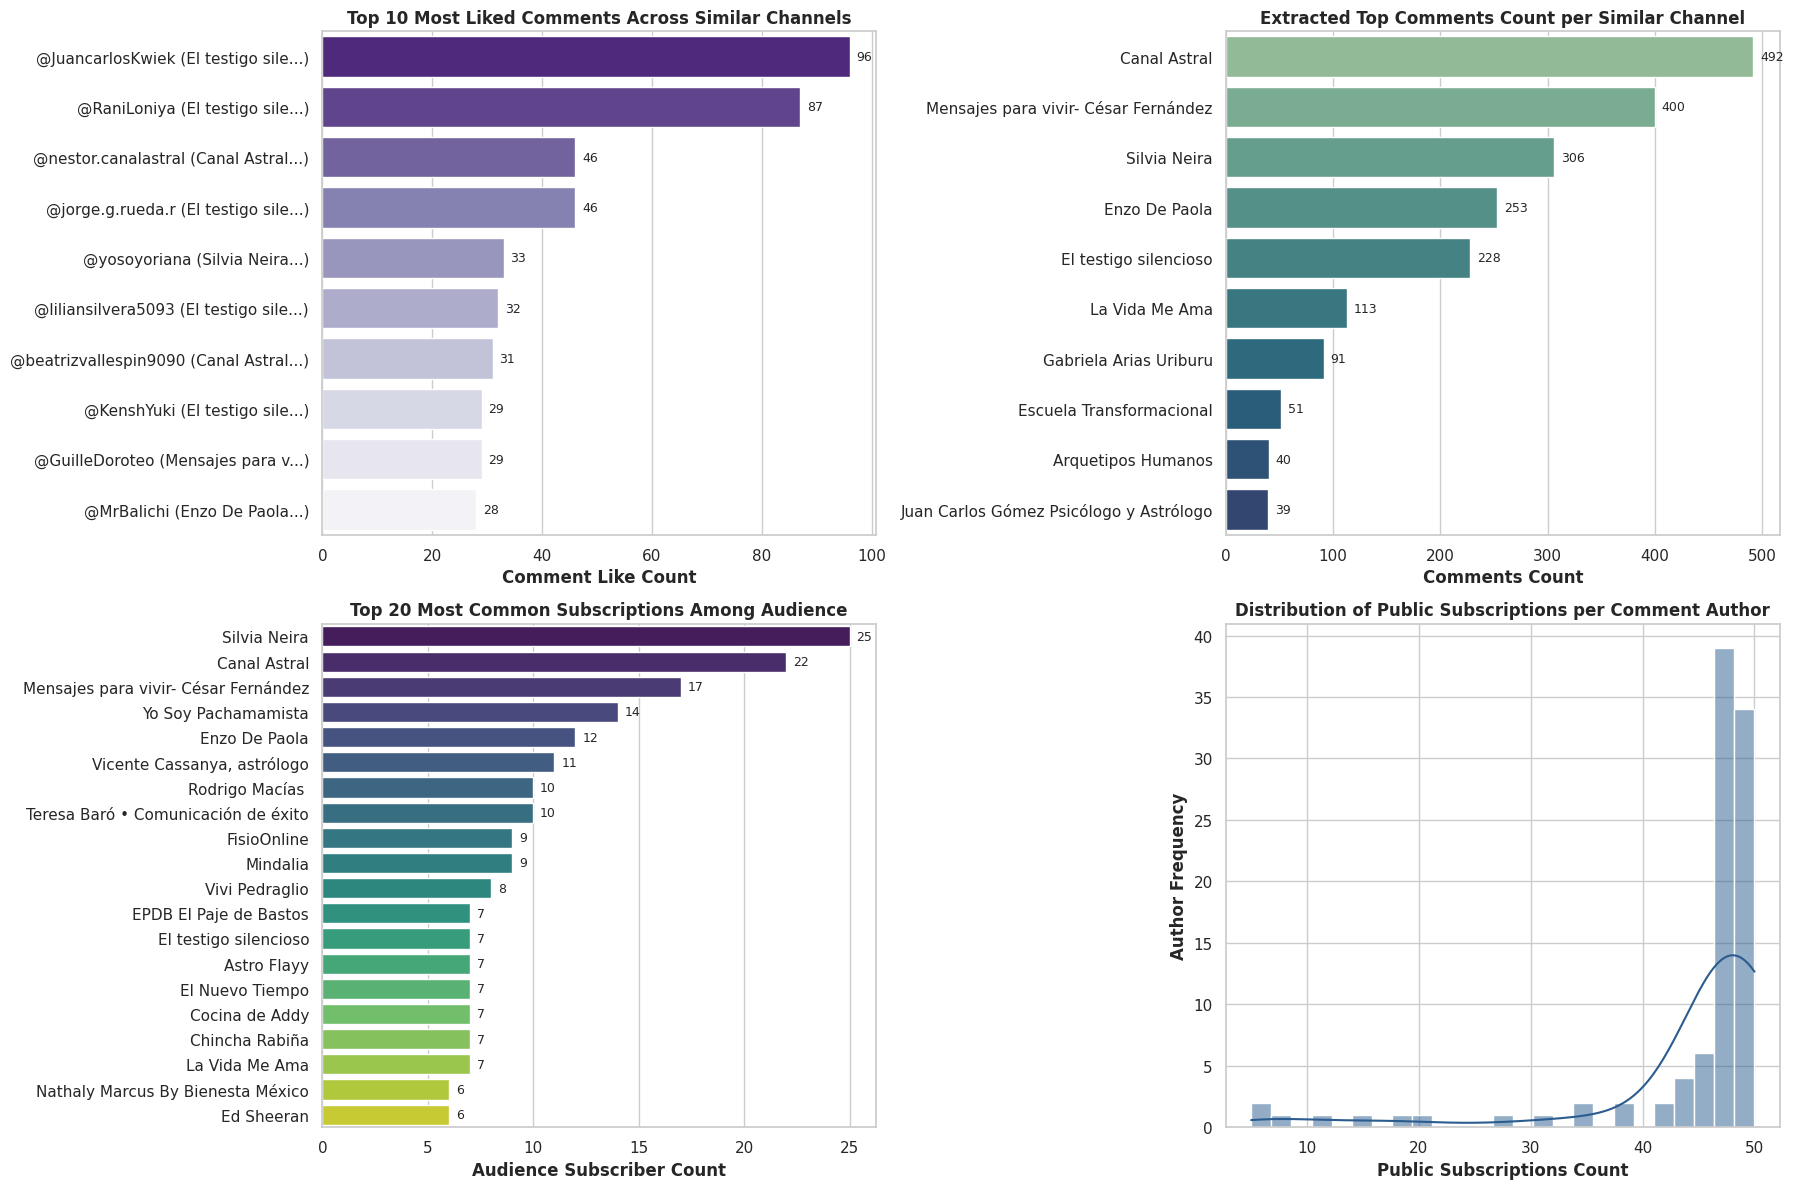

📊 Visual analytics charts rendered inline and saved to: '/content/drive/MyDrive/YouTube_Analytics/Casa_Siete_similar_channels_comments_and_subs_analytics.png'


In [28]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 10, 'figure.titlesize': 14})

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Chart 1: Top 10 Most Liked Comments Across Similar Channels
if not df_comments.empty and "like_count" in df_comments.columns:
    top_liked = df_comments.sort_values(by="like_count", ascending=False).head(10).copy()
    top_liked["label"] = top_liked["author_name"] + " (" + top_liked["similar_channel_title"].str[:15] + "...)"
    sns.barplot(data=top_liked, x="like_count", y="label", ax=axes[0, 0], palette="Purples_r", hue="label", legend=False)
    axes[0, 0].set_title("Top 10 Most Liked Comments Across Similar Channels", fontweight="bold")
    axes[0, 0].set_xlabel("Comment Like Count", fontweight="bold")
    axes[0, 0].set_ylabel("")
    for p in axes[0, 0].patches:
        w = p.get_width()
        axes[0, 0].annotate(f"{int(w):,}", (w, p.get_y() + p.get_height() / 2.),
                            ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)
else:
    axes[0, 0].text(0.5, 0.5, "No Comments Data Available", ha="center", va="center", fontsize=12)

# Chart 2: Extracted Top Comments per Similar Channel
if not df_comments.empty and "similar_channel_title" in df_comments.columns:
    ch_counts = df_comments["similar_channel_title"].value_counts().reset_index()
    ch_counts.columns = ["similar_channel_title", "comment_count"]
    sns.barplot(data=ch_counts, x="comment_count", y="similar_channel_title", ax=axes[0, 1], palette="crest", hue="similar_channel_title", legend=False)
    axes[0, 1].set_title("Extracted Top Comments Count per Similar Channel", fontweight="bold")
    axes[0, 1].set_xlabel("Comments Count", fontweight="bold")
    axes[0, 1].set_ylabel("")
    for p in axes[0, 1].patches:
        w = p.get_width()
        axes[0, 1].annotate(f"{int(w):,}", (w, p.get_y() + p.get_height() / 2.),
                            ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)
else:
    axes[0, 1].text(0.5, 0.5, "No Comments Data Available", ha="center", va="center", fontsize=12)

# Chart 3: Top 20 Most Common Subscriptions
if not df_agg_subs.empty:
    top_20_subs = df_agg_subs.head(20)
    sns.barplot(data=top_20_subs, x="subscriber_count", y="subscribed_channel_title", ax=axes[1, 0], palette="viridis", hue="subscribed_channel_title", legend=False)
    axes[1, 0].set_title("Top 20 Most Common Subscriptions Among Audience", fontweight="bold")
    axes[1, 0].set_xlabel("Audience Subscriber Count", fontweight="bold")
    axes[1, 0].set_ylabel("")
    for p in axes[1, 0].patches:
        w = p.get_width()
        axes[1, 0].annotate(f"{int(w):,}", (w, p.get_y() + p.get_height() / 2.),
                            ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)
else:
    axes[1, 0].text(0.5, 0.5, "No Subscriptions Data Available", ha="center", va="center", fontsize=12)

# Chart 4: Public Subscriptions per Author Distribution
if not df_raw_subs.empty and "author_channel_id" in df_raw_subs.columns:
    author_sub_counts = df_raw_subs.groupby("author_channel_id")["subscribed_channel_id"].count()
    sns.histplot(author_sub_counts, bins=25, kde=True, ax=axes[1, 1], color="#2b5c8f")
    axes[1, 1].set_title("Distribution of Public Subscriptions per Comment Author", fontweight="bold")
    axes[1, 1].set_xlabel("Public Subscriptions Count", fontweight="bold")
    axes[1, 1].set_ylabel("Author Frequency", fontweight="bold")
else:
    axes[1, 1].text(0.5, 0.5, "No Subscriptions Data Available", ha="center", va="center", fontsize=12)

plt.tight_layout()
plot_path = os.path.join(ACTIVE_OUTPUT_DIR, f"{safe_channel_id}_similar_channels_comments_and_subs_analytics.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 Visual analytics charts rendered inline and saved to: '{plot_path}'")
